# Validación Geográfica LOBO (Leave-One-Block-Out)

## Imports y configuración

In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb

from imblearn.over_sampling import BorderlineSMOTE
from scipy.stats import ks_2samp
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, average_precision_score,
                             brier_score_loss, f1_score, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Rutas
BASE_DIR = '..' if os.path.exists('../data/processed/data_procesada.csv') else '.'
DATA_PATH = f"{BASE_DIR}/data/processed/data_procesada.csv"
OUTPUT_DIR = 'outputs_LOBO' if BASE_DIR == '..' else 'notebooks/outputs_LOBO'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('=== Validacion Geografica LOBO ===')
print(f'Datos : {DATA_PATH}')
print(f'Output: {OUTPUT_DIR}')

=== Validacion Geografica LOBO ===
Datos : ../data/processed/data_procesada.csv
Output: outputs_LOBO


## Cargar datos y FE

In [2]:
def crear_features_geoquimicos(df: pd.DataFrame) -> pd.DataFrame:
    df_fe = df.copy()
    ratios = {
        'Au_Cu_ratio': ('Au_ppm', 'Cu_ppm'),
        'Au_Ag_ratio': ('Au_ppm', 'Ag_ppm'),
        'Au_As_ratio': ('Au_ppm', 'As_ppm'),
        'Au_Sb_ratio': ('Au_ppm', 'Sb_ppm'),
        'As_Sb_ratio': ('As_ppm', 'Sb_ppm'),
        'Cu_Ag_ratio': ('Cu_ppm', 'Ag_ppm'),
        'Pb_Zn_ratio': ('Pb_ppm', 'Zn_ppm'),
        'Bi_As_ratio': ('Bi_ppm', 'As_ppm'),
    }
    for name, (num, den) in ratios.items():
        if num in df_fe.columns and den in df_fe.columns:
            df_fe[name] = df_fe[num] / df_fe[den].replace(0, np.nan)
    pathfinders = ['As_ppm', 'Sb_ppm', 'Cu_ppm', 'Ag_ppm', 'Bi_ppm', 'Pb_ppm', 'Zn_ppm']
    available = [c for c in pathfinders if c in df_fe.columns]
    if available:
        df_fe['pathfinder_sum'] = df_fe[available].sum(axis=1)
        df_fe['pathfinder_mean'] = df_fe[available].mean(axis=1)
        df_fe['pathfinder_max'] = df_fe[available].max(axis=1)
    return df_fe

df = pd.read_csv(DATA_PATH)
df_fe = crear_features_geoquimicos(df)

EXCLUDE = ['target_Au', 'Au_ppm', 'East', 'North', 'Level']
FEATURES = [c for c in df_fe.columns if c not in EXCLUDE]

print(f'Dataset : {df.shape[0]} muestras, {df.shape[1]} columnas originales')
print(f'Features del modelo: {len(FEATURES)}')
print(f'Target  : {df_fe.target_Au.value_counts().to_dict()} '
      f'({100*df_fe.target_Au.mean():.1f}% positivos)')

Dataset : 2132 muestras, 51 columnas originales
Features del modelo: 57
Target  : {0: 1872, 1: 260} (12.2% positivos)


## Definición de bloques geográficos

Mediana East = 6552.9 | Mediana North = 6988.2
          n  n_pos  pct_pos
bloque                     
NE      555     52     9.37
NO      511     74    14.48
SO      555    108    19.46
SE      511     26     5.09


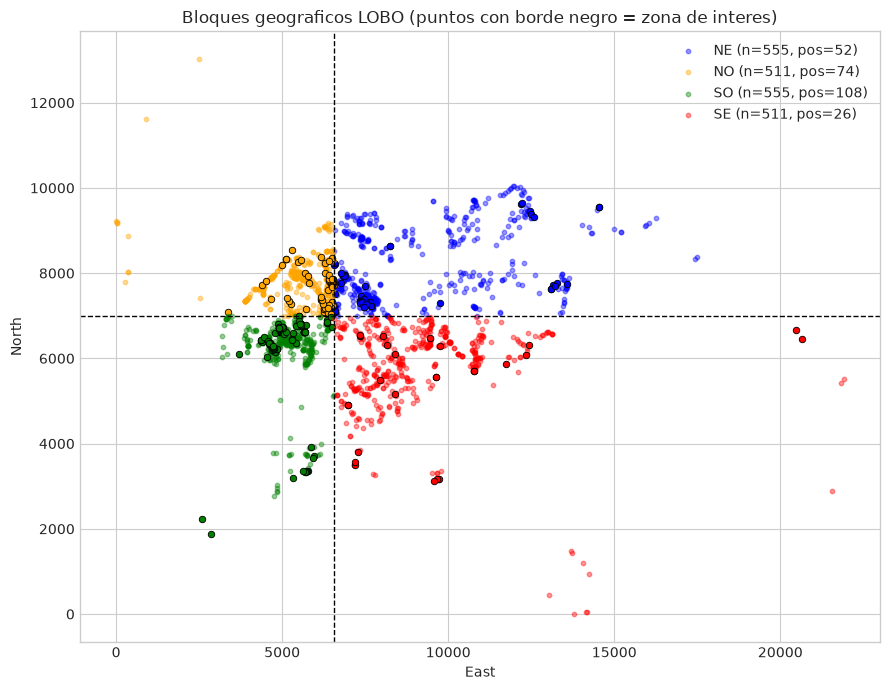

In [3]:
east_med = df_fe['East'].median()
north_med = df_fe['North'].median()

def asignar_bloque(row):
    if row['East'] >= east_med and row['North'] >= north_med: return 'NE'
    elif row['East'] < east_med and row['North'] >= north_med: return 'NO'
    elif row['East'] < east_med and row['North'] < north_med: return 'SO'
    else: return 'SE'

df_fe['bloque'] = df_fe.apply(asignar_bloque, axis=1)
BLOQUES = ['NE', 'NO', 'SO', 'SE']

resumen_bloques = (df_fe.groupby('bloque')
                   .agg(n=('target_Au', 'size'), n_pos=('target_Au', 'sum'))
                   .reindex(BLOQUES))
resumen_bloques['pct_pos'] = (100 * resumen_bloques['n_pos'] / resumen_bloques['n']).round(2)
resumen_bloques.to_csv(f'{OUTPUT_DIR}/lobo_resumen_bloques.csv')
print(f'Mediana East = {east_med:.1f} | Mediana North = {north_med:.1f}')
print(resumen_bloques)

# Mapa de bloques
fig, ax = plt.subplots(figsize=(9, 7))
colors = {'NE': 'blue', 'NO': 'orange', 'SO': 'green', 'SE': 'red'}
for b in BLOQUES:
    sub = df_fe[df_fe['bloque'] == b]
    ax.scatter(sub['East'], sub['North'], s=10, alpha=0.4, c=colors[b],
               label=f"{b} (n={len(sub)}, pos={int(sub.target_Au.sum())})")
    pos = sub[sub['target_Au'] == 1]
    ax.scatter(pos['East'], pos['North'], s=22, c=colors[b], edgecolors='k', linewidths=0.6)
ax.axvline(east_med, color='k', ls='--', lw=1)
ax.axhline(north_med, color='k', ls='--', lw=1)
ax.set_xlabel('East'); ax.set_ylabel('North')
ax.set_title('Bloques geograficos LOBO (puntos con borde negro = zona de interes)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lobo_mapa_bloques.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()

## Entrenamiento y funciones de evaluación

In [4]:
XGB_PARAMS = {
    'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3,
    'random_state': SEED, 'eval_metric': 'aucpr', 'tree_method': 'hist',
}

def entrenar_pipeline(X_tr, y_tr):
    """Ajusta imputador+log1p+SMOTE+scaler+XGBoost SOLO con datos de train."""
    imputer = SimpleImputer(strategy='median')
    X_tr_imp = imputer.fit_transform(X_tr)
    X_tr_log = np.log1p(np.clip(X_tr_imp, a_min=-0.999, a_max=None))
    smote = BorderlineSMOTE(sampling_strategy='auto', random_state=SEED, kind='borderline-1')
    X_bal_log, y_bal = smote.fit_resample(X_tr_log, y_tr)
    scaler = StandardScaler()
    X_bal_scaled = scaler.fit_transform(X_bal_log)
    model = xgb.XGBClassifier(**XGB_PARAMS)
    model.fit(X_bal_scaled, y_bal)
    return model, imputer, scaler

def transformar(X, imputer, scaler):
    X_imp = imputer.transform(X)
    X_log = np.log1p(np.clip(X_imp, a_min=-0.999, a_max=None))
    return scaler.transform(X_log)

def evaluar_bloque(y_true, y_prob, y_pred, n_boot=1000, conf=0.95):
    """Metricas + IC 95% bootstrap (misma logica que evaluar_slice de Sprint 4)."""
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob); y_pred = np.asarray(y_pred)
    n, n_pos = len(y_true), int(y_true.sum())
    out = {'n': n, 'n_pos': n_pos,
           'Accuracy': accuracy_score(y_true, y_pred),
           'Precision': precision_score(y_true, y_pred, zero_division=0),
           'Recall': recall_score(y_true, y_pred, zero_division=0),
           'F1': f1_score(y_true, y_pred, zero_division=0),
           'PR_AUC': average_precision_score(y_true, y_prob),
           'ROC_AUC': roc_auc_score(y_true, y_prob),
           'Brier': brier_score_loss(y_true, y_prob)}
    rng = np.random.RandomState(SEED)
    bf1, bpr, broc = [], [], []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        bf1.append(f1_score(y_true[idx], y_pred[idx], zero_division=0))
        bpr.append(average_precision_score(y_true[idx], y_prob[idx]))
        broc.append(roc_auc_score(y_true[idx], y_prob[idx]))
    a = (1 - conf) / 2
    ci = lambda arr: (np.percentile(arr, 100 * a), np.percentile(arr, 100 * (1 - a))) if arr else (np.nan, np.nan)
    out['F1_CI_low'], out['F1_CI_high'] = ci(bf1)
    out['PR_AUC_CI_low'], out['PR_AUC_CI_high'] = ci(bpr)
    out['ROC_AUC_CI_low'], out['ROC_AUC_CI_high'] = ci(broc)
    return out

def psi_feature(expected, actual, bins=10):
    """Population Stability Index entre distribucion train (expected) y bloque held-out (actual)."""
    expected = np.asarray(expected, dtype=float); actual = np.asarray(actual, dtype=float)
    qs = np.unique(np.nanquantile(expected, np.linspace(0, 1, bins + 1)))
    if len(qs) < 3:
        return 0.0
    qs[0], qs[-1] = -np.inf, np.inf
    e_pct = np.histogram(expected, bins=qs)[0] / max(len(expected), 1)
    a_pct = np.histogram(actual, bins=qs)[0] / max(len(actual), 1)
    e_pct = np.clip(e_pct, 1e-4, None); a_pct = np.clip(a_pct, 1e-4, None)
    return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))

print('Pipeline y funciones listas |', len(FEATURES), 'features |', XGB_PARAMS)

Pipeline y funciones listas | 57 features | {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'random_state': 42, 'eval_metric': 'aucpr', 'tree_method': 'hist'}


## Loop LOBO: entrenar con N-1 bloques

In [5]:
metricas_lobo, psi_rows, ks_rows, shap_rows = [], [], [], []
predicciones = []

for b in BLOQUES:
    train_mask = df_fe['bloque'] != b
    test_mask = df_fe['bloque'] == b
    X_tr, y_tr = df_fe.loc[train_mask, FEATURES], df_fe.loc[train_mask, 'target_Au']
    X_te, y_te = df_fe.loc[test_mask, FEATURES], df_fe.loc[test_mask, 'target_Au']

    model, imputer, scaler = entrenar_pipeline(X_tr, y_tr)
    X_te_scaled = transformar(X_te, imputer, scaler)
    y_prob = model.predict_proba(X_te_scaled)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    m = evaluar_bloque(y_te, y_prob, y_pred)
    m['Bloque'] = b
    m['n_train'] = int(train_mask.sum())
    metricas_lobo.append(m)

    pred_df = df_fe.loc[test_mask, ['East', 'North', 'Level', 'Au_ppm', 'target_Au', 'bloque']].copy()
    pred_df['y_prob'], pred_df['y_pred'] = y_prob, y_pred
    predicciones.append(pred_df)

    # --- Monitoreo de shift: PSI y KS por feature (train N-1 bloques vs bloque held-out) ---
    X_tr_imp = pd.DataFrame(imputer.transform(X_tr), columns=FEATURES)
    X_te_imp = pd.DataFrame(imputer.transform(X_te), columns=FEATURES)
    for f in FEATURES:
        psi_rows.append({'Bloque': b, 'Feature': f,
                         'PSI': psi_feature(X_tr_imp[f], X_te_imp[f])})
        ks_stat, ks_p = ks_2samp(X_tr_imp[f], X_te_imp[f])
        ks_rows.append({'Bloque': b, 'Feature': f, 'KS_stat': ks_stat, 'p_value': ks_p})

    # --- SHAP top-10 sobre el bloque held-out ---
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_te_scaled)
    mean_abs = np.abs(shap_vals).mean(axis=0)
    orden = np.argsort(mean_abs)[::-1]
    for rank, idx in enumerate(orden[:10], start=1):
        shap_rows.append({'Bloque': b, 'Rank': rank, 'Feature': FEATURES[idx],
                          'mean_abs_SHAP': float(mean_abs[idx])})

    print(f"Bloque {b}: train={m['n_train']} test={m['n']} (pos={m['n_pos']}) | "
          f"F1={m['F1']:.4f} [{m['F1_CI_low']:.3f}-{m['F1_CI_high']:.3f}] | "
          f"PR-AUC={m['PR_AUC']:.4f} | Brier={m['Brier']:.4f}")

df_lobo = pd.DataFrame(metricas_lobo)[
    ['Bloque', 'n_train', 'n', 'n_pos', 'Accuracy', 'Precision', 'Recall', 'F1',
     'F1_CI_low', 'F1_CI_high', 'PR_AUC', 'PR_AUC_CI_low', 'PR_AUC_CI_high',
     'ROC_AUC', 'ROC_AUC_CI_low', 'ROC_AUC_CI_high', 'Brier']]
df_lobo.to_csv(f'{OUTPUT_DIR}/lobo_metricas_por_bloque.csv', index=False)

df_pred = pd.concat(predicciones, ignore_index=True)
df_pred.to_csv(f'{OUTPUT_DIR}/lobo_predicciones.csv', index=False)

df_psi = pd.DataFrame(psi_rows)
df_ks = pd.DataFrame(ks_rows)
df_shap = pd.DataFrame(shap_rows)
df_psi.to_csv(f'{OUTPUT_DIR}/lobo_psi_por_bloque.csv', index=False)
df_ks.to_csv(f'{OUTPUT_DIR}/lobo_ks_por_bloque.csv', index=False)
df_shap.to_csv(f'{OUTPUT_DIR}/lobo_shap_top10_por_bloque.csv', index=False)

print('\nResumen LOBO:')
print(f"  F1 medio     = {df_lobo['F1'].mean():.4f} ± {df_lobo['F1'].std():.4f}")
print(f"  PR-AUC medio = {df_lobo['PR_AUC'].mean():.4f} ± {df_lobo['PR_AUC'].std():.4f}")
print(f"  Brier medio  = {df_lobo['Brier'].mean():.4f} ± {df_lobo['Brier'].std():.4f}")

Bloque NE: train=1577 test=555 (pos=52) | F1=0.9346 [0.870-0.977] | PR-AUC=0.9863 | Brier=0.0095
Bloque NO: train=1621 test=511 (pos=74) | F1=0.9733 [0.943-0.994] | PR-AUC=0.9975 | Brier=0.0063
Bloque SO: train=1577 test=555 (pos=108) | F1=0.9364 [0.899-0.967] | PR-AUC=0.9865 | Brier=0.0209
Bloque SE: train=1621 test=511 (pos=26) | F1=0.9231 [0.828-0.982] | PR-AUC=0.9909 | Brier=0.0046

Resumen LOBO:
  F1 medio     = 0.9418 ± 0.0218
  PR-AUC medio = 0.9903 ± 0.0052
  Brier medio  = 0.0103 ± 0.0073


## Validación interna de referencia (CV 5-fold estratificada)

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_all, y_all = df_fe[FEATURES], df_fe['target_Au']

cv_rows = []
for i, (tr_idx, te_idx) in enumerate(skf.split(X_all, y_all), start=1):
    X_tr, y_tr = X_all.iloc[tr_idx], y_all.iloc[tr_idx]
    X_te, y_te = X_all.iloc[te_idx], y_all.iloc[te_idx]
    model, imputer, scaler = entrenar_pipeline(X_tr, y_tr)
    X_te_scaled = transformar(X_te, imputer, scaler)
    y_prob = model.predict_proba(X_te_scaled)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    cv_rows.append({'Fold': i,
                    'F1': f1_score(y_te, y_pred, zero_division=0),
                    'PR_AUC': average_precision_score(y_te, y_prob),
                    'ROC_AUC': roc_auc_score(y_te, y_prob),
                    'Brier': brier_score_loss(y_te, y_prob)})
    print(f"Fold {i}: F1={cv_rows[-1]['F1']:.4f} PR-AUC={cv_rows[-1]['PR_AUC']:.4f} "
          f"Brier={cv_rows[-1]['Brier']:.4f}")

df_cv = pd.DataFrame(cv_rows)
df_cv.to_csv(f'{OUTPUT_DIR}/lobo_cv5fold_referencia.csv', index=False)
F1_CV, PR_CV, BRIER_CV = df_cv['F1'].mean(), df_cv['PR_AUC'].mean(), df_cv['Brier'].mean()
print(f'\nCV 5-fold: F1={F1_CV:.4f} ± {df_cv.F1.std():.4f} | '
      f'PR-AUC={PR_CV:.4f} ± {df_cv.PR_AUC.std():.4f} | Brier={BRIER_CV:.4f}')

Fold 1: F1=0.9515 PR-AUC=0.9946 Brier=0.0073
Fold 2: F1=0.9245 PR-AUC=0.9877 Brier=0.0121
Fold 3: F1=0.9455 PR-AUC=0.9940 Brier=0.0108
Fold 4: F1=0.9808 PR-AUC=0.9996 Brier=0.0031
Fold 5: F1=0.9346 PR-AUC=0.9919 Brier=0.0100

CV 5-fold: F1=0.9474 ± 0.0213 | PR-AUC=0.9935 ± 0.0044 | Brier=0.0087


## Comparación LOBO vs CV 5-fold

Bloque   n  n_pos     F1  F1_CI_low  F1_CI_high  PR_AUC  Brier  F1_CV_ref  Delta_F1  PR_AUC_CV_ref  Delta_PR_AUC  Delta_Brier  Cumple_H3
    NE 555     52 0.9346     0.8704      0.9773  0.9863 0.0095     0.9474    0.0128         0.9935        0.0073       0.0009       True
    NO 511     74 0.9733     0.9434      0.9942  0.9975 0.0063     0.9474   -0.0260         0.9935       -0.0039      -0.0024       True
    SO 555    108 0.9364     0.8992      0.9672  0.9865 0.0209     0.9474    0.0110         0.9935        0.0071       0.0122       True
    SE 511     26 0.9231     0.8276      0.9818  0.9909 0.0046     0.9474    0.0243         0.9935        0.0026      -0.0041       True

F1 CV 5-fold (interna) = 0.9474
F1 LOBO medio (externa-geografica) = 0.9418 ± 0.0218
Delta F1 medio = 0.0055 -> criterio H3 (<= 0.05): CUMPLE
Bloques que cumplen individualmente: 4/4


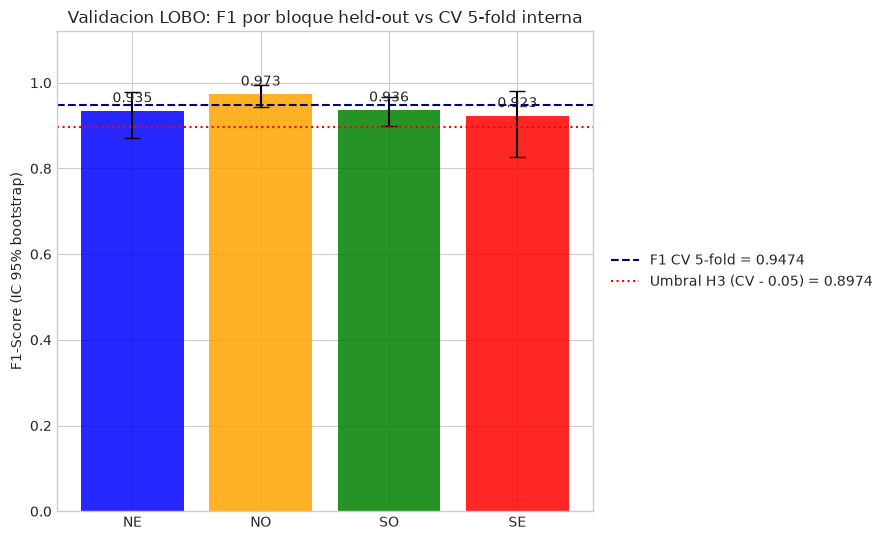

In [8]:
comp = df_lobo[['Bloque', 'n', 'n_pos', 'F1', 'F1_CI_low', 'F1_CI_high',
                'PR_AUC', 'Brier']].copy()
comp['F1_CV_ref'] = F1_CV
comp['Delta_F1'] = F1_CV - comp['F1']
comp['PR_AUC_CV_ref'] = PR_CV
comp['Delta_PR_AUC'] = PR_CV - comp['PR_AUC']
comp['Delta_Brier'] = comp['Brier'] - BRIER_CV
comp['Cumple_H3'] = comp['Delta_F1'] <= 0.05
comp.to_csv(f'{OUTPUT_DIR}/lobo_vs_cv_comparacion.csv', index=False)
print(comp.round(4).to_string(index=False))

delta_medio = F1_CV - df_lobo['F1'].mean()
print(f"\nF1 CV 5-fold (interna) = {F1_CV:.4f}")
print(f"F1 LOBO medio (externa-geografica) = {df_lobo['F1'].mean():.4f} ± {df_lobo['F1'].std():.4f}")
print(f"Delta F1 medio = {delta_medio:.4f} -> criterio H3 (<= 0.05): "
      f"{'CUMPLE' if delta_medio <= 0.05 else 'NO CUMPLE'}")
print(f"Bloques que cumplen individualmente: {int(comp['Cumple_H3'].sum())}/4")

# Grafico de barras F1 con IC 95%
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(comp))
err = np.array([comp['F1'] - comp['F1_CI_low'], comp['F1_CI_high'] - comp['F1']])
bars = ax.bar(x, comp['F1'], yerr=err, capsize=6,
              color=[colors[b] for b in comp['Bloque']], alpha=0.85)
ax.axhline(F1_CV, color='navy', ls='--', lw=1.5, label=f'F1 CV 5-fold = {F1_CV:.4f}')
ax.axhline(F1_CV - 0.05, color='red', ls=':', lw=1.5,
           label=f'Umbral H3 (CV - 0.05) = {F1_CV - 0.05:.4f}')
for xi, f1v in zip(x, comp['F1']):
    ax.text(xi, min(f1v + 0.02, 1.06), f'{f1v:.3f}', ha='center', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(comp['Bloque'])
ax.set_ylim(0, 1.12); ax.set_ylabel('F1-Score (IC 95% bootstrap)')
ax.set_title('Validacion LOBO: F1 por bloque held-out vs CV 5-fold interna')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lobo_f1_por_bloque.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()

## Monitoreo de dataset shift entre bloques

=== PSI y KS por bloque ===
Bloque  PSI_max Feature_PSI_max  n_features_PSI>0.20  Alerta_PSI  n_features_KS_p<0.05  Alerta_KS
    NE   0.2577          Zr_ppm                    3        True                    45       True
    NO   0.8266          Ca_per                   30        True                    53       True
    SO   0.8684     Au_Sb_ratio                   17        True                    52       True
    SE   0.4342          Mn_ppm                   12        True                    52       True


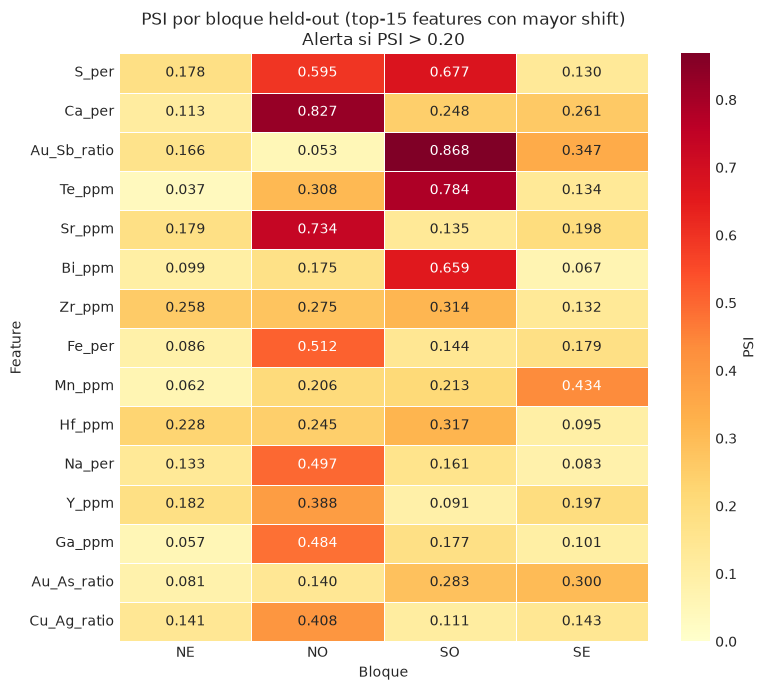


Top-10 features con KS significativo mas frecuente:
Feature
Ag_ppm         4
Al_per         4
As_Sb_ratio    4
Au_Ag_ratio    4
Au_As_ratio    4
Ce_ppm         4
Bi_ppm         4
Be_ppm         4
Ge_ppm         4
Ga_ppm         4
dtype: int64


In [9]:
alertas = []
for b in BLOQUES:
    psi_b = df_psi[df_psi['Bloque'] == b]
    ks_b = df_ks[df_ks['Bloque'] == b]
    n_psi_alerta = int((psi_b['PSI'] > 0.20).sum())
    n_ks_signif = int((ks_b['p_value'] < 0.05).sum())
    alertas.append({'Bloque': b,
                    'PSI_max': psi_b['PSI'].max(),
                    'Feature_PSI_max': psi_b.loc[psi_b['PSI'].idxmax(), 'Feature'],
                    'n_features_PSI>0.20': n_psi_alerta,
                    'Alerta_PSI': n_psi_alerta > 0,
                    'n_features_KS_p<0.05': n_ks_signif,
                    'Alerta_KS': n_ks_signif >= 5})

df_alertas = pd.DataFrame(alertas)
print('=== PSI y KS por bloque ===')
print(df_alertas.round(4).to_string(index=False))

# Heatmap PSI: top-15 features con mayor PSI medio
top_feats = (df_psi.groupby('Feature')['PSI'].mean()
             .sort_values(ascending=False).head(15).index)
pivot = df_psi[df_psi['Feature'].isin(top_feats)].pivot(
    index='Feature', columns='Bloque', values='PSI').reindex(top_feats)[BLOQUES]
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=max(0.4, pivot.values.max()),
            cbar_kws={'label': 'PSI'}, linewidths=0.5, ax=ax)
ax.set_title('PSI por bloque held-out (top-15 features con mayor shift)\nAlerta si PSI > 0.20')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lobo_psi_heatmap.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()

print('\nTop-10 features con KS significativo mas frecuente:')
print(df_ks[df_ks['p_value'] < 0.05].groupby('Feature').size()
      .sort_values(ascending=False).head(10))

## Comparación del ranking SHAP top-10 entre bloques

=== Top-10 SHAP por bloque held-out ===
Bloque           NE           NO           SO           SE
Rank                                                      
1       Au_Sb_ratio  Au_Sb_ratio  Au_Sb_ratio  Au_Sb_ratio
2            Sb_ppm  Au_Cu_ratio       Sb_ppm  Au_Cu_ratio
3       Au_Cu_ratio       Ag_ppm  Au_Cu_ratio       Sb_ppm
4            Ag_ppm       Sb_ppm       Ag_ppm       Ag_ppm
5       Au_Ag_ratio  Au_Ag_ratio       As_ppm  Au_Ag_ratio
6            Te_ppm       Te_ppm  Au_Ag_ratio       As_ppm
7            Cu_ppm       As_ppm       Te_ppm       Te_ppm
8            Tl_ppm  Au_As_ratio       Cu_ppm       Cu_ppm
9       Au_As_ratio       Cu_ppm       Mo_ppm       Se_ppm
10           Se_ppm       Se_ppm  Au_As_ratio       Mo_ppm

Ranking global (media entre bloques): ['Au_Sb_ratio', 'Sb_ppm', 'Au_Cu_ratio', 'Ag_ppm', 'Au_Ag_ratio', 'As_ppm', 'Te_ppm', 'Cu_ppm', 'Au_As_ratio', 'Tl_ppm']

Bloque  Top10_comunes_con_global  Alerta_SHAP
    NE                         9        False

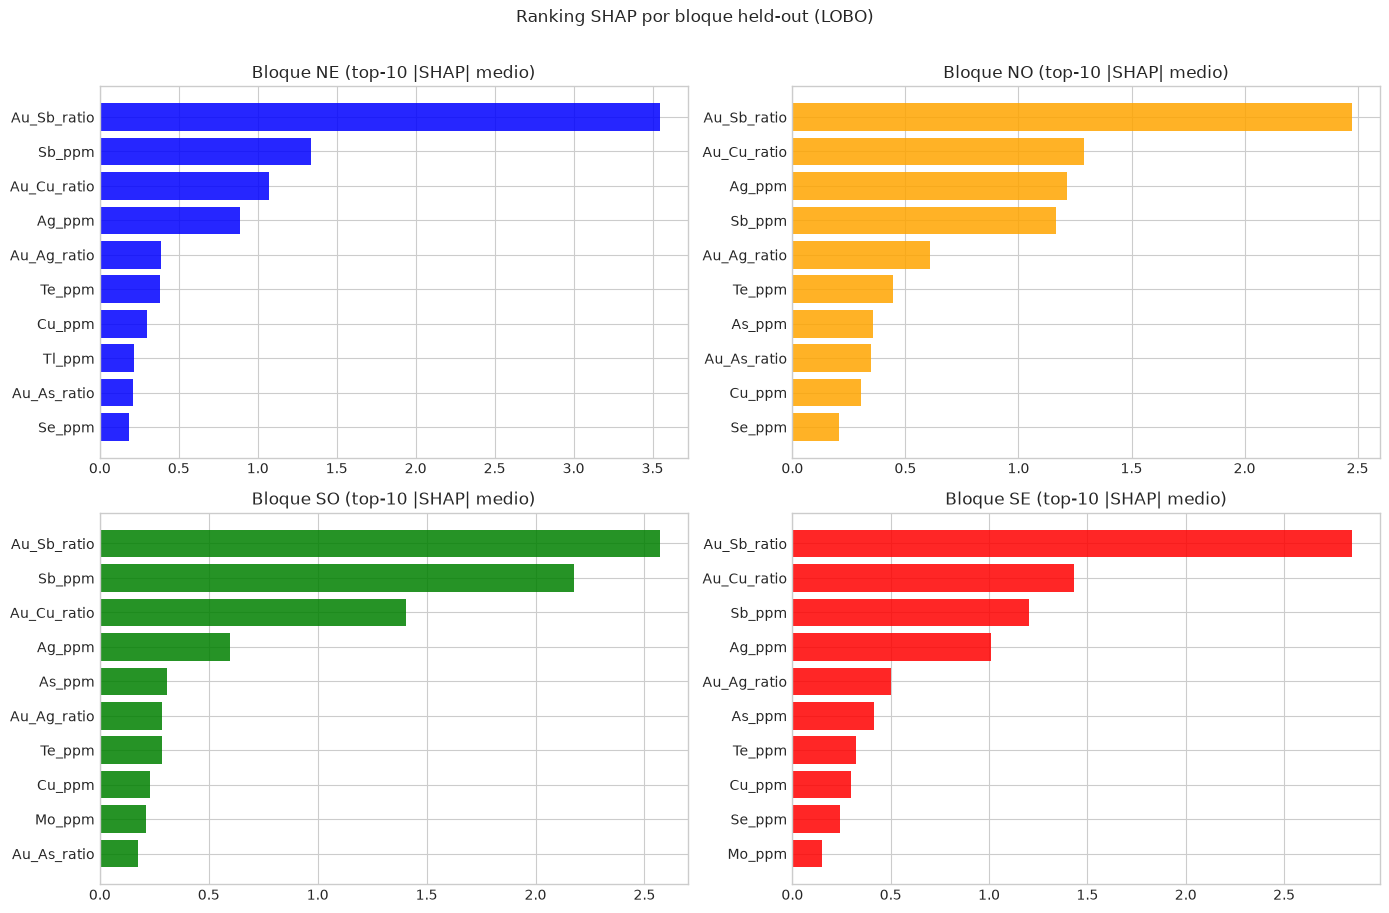

In [10]:
tabla_shap = df_shap.pivot(index='Rank', columns='Bloque', values='Feature')[BLOQUES]
print('=== Top-10 SHAP por bloque held-out ===')
print(tabla_shap.to_string())

# Ranking global de referencia: frecuencia + importancia media entre bloques
ranking_global = (df_shap.groupby('Feature')['mean_abs_SHAP'].mean()
                  .sort_values(ascending=False).head(10).index.tolist())
print('\nRanking global (media entre bloques):', ranking_global)

overlap_rows = []
for b in BLOQUES:
    top_b = df_shap[df_shap['Bloque'] == b].sort_values('Rank')['Feature'].tolist()
    inter = len(set(top_b) & set(ranking_global))
    overlap_rows.append({'Bloque': b, 'Top10_comunes_con_global': inter,
                         'Alerta_SHAP': inter < 7})
df_overlap = pd.DataFrame(overlap_rows)
print('\n' + df_overlap.to_string(index=False))

# Consolidado de alertas y regla de reentrenamiento (>= 2 alertas)
df_alertas = df_alertas.merge(df_overlap, on='Bloque')
df_alertas['n_alertas'] = (df_alertas[['Alerta_PSI', 'Alerta_KS', 'Alerta_SHAP']].sum(axis=1))
df_alertas['Requiere_reentrenar'] = df_alertas['n_alertas'] >= 2
df_alertas.to_csv(f'{OUTPUT_DIR}/lobo_alertas_shift.csv', index=False)
print('\n=== Consolidado de alertas de shift ===')
print(df_alertas[['Bloque', 'Alerta_PSI', 'Alerta_KS', 'Alerta_SHAP',
                  'n_alertas', 'Requiere_reentrenar']].to_string(index=False))

# Grafico comparativo de importancias SHAP
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)
for ax, b in zip(axes.ravel(), BLOQUES):
    sub = df_shap[df_shap['Bloque'] == b].sort_values('mean_abs_SHAP')
    ax.barh(sub['Feature'], sub['mean_abs_SHAP'], color=colors[b], alpha=0.85)
    ax.set_title(f'Bloque {b} (top-10 |SHAP| medio)')
plt.suptitle('Ranking SHAP por bloque held-out (LOBO)', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lobo_shap_por_bloque.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()

## Resumen

In [11]:
peor = df_lobo.loc[df_lobo['F1'].idxmin()]
mejor = df_lobo.loc[df_lobo['F1'].idxmax()]
delta_medio = F1_CV - df_lobo['F1'].mean()
cumple_h3 = delta_medio <= 0.05
n_bloques_ok = int((F1_CV - df_lobo['F1'] <= 0.05).sum())

resumen = f"""
================================================================
RESUMEN EJECUTIVO - VALIDACION GEOGRAFICA LOBO
================================================================
Dataset: {len(df_fe)} muestras | {len(FEATURES)} features | K=4 bloques (grilla por medianas East/North)
Pipeline por fold: imputacion mediana -> log1p -> BorderlineSMOTE (solo train) -> StandardScaler -> XGBoost Optuna (seed=42)

1) VALIDACION INTERNA (CV 5-fold estratificada, mismo pipeline):
   F1 = {F1_CV:.4f} ± {df_cv['F1'].std():.4f} | PR-AUC = {PR_CV:.4f} | Brier = {BRIER_CV:.4f}

2) VALIDACION EXTERNA-GEOGRAFICA (LOBO):
   F1 medio = {df_lobo['F1'].mean():.4f} ± {df_lobo['F1'].std():.4f}
   PR-AUC medio = {df_lobo['PR_AUC'].mean():.4f} ± {df_lobo['PR_AUC'].std():.4f}
   Brier medio = {df_lobo['Brier'].mean():.4f} ± {df_lobo['Brier'].std():.4f}
   Mejor bloque : {mejor['Bloque']} (F1 = {mejor['F1']:.4f})
   Peor bloque  : {peor['Bloque']} (F1 = {peor['F1']:.4f}, IC95 [{peor['F1_CI_low']:.3f}, {peor['F1_CI_high']:.3f}])

3) CONTRASTE H3 (caida F1 <= 0.05 vs CV 5-fold):
   Delta F1 medio = {delta_medio:.4f} -> {'CUMPLE' if cumple_h3 else 'NO CUMPLE'}
   Bloques que cumplen individualmente: {n_bloques_ok}/4

4) MONITOREO DE SHIFT:
{df_alertas[['Bloque', 'PSI_max', 'n_features_PSI>0.20', 'n_features_KS_p<0.05',
             'Top10_comunes_con_global', 'n_alertas', 'Requiere_reentrenar']].round(3).to_string(index=False)}

5) LIMITACION (trabajo futuro):
   El LOBO opera dentro del dataset disponible (Ancash). La transferibilidad a
   yacimientos de otras regiones requiere datasets adicionales.
================================================================
"""
print(resumen)
with open(f'{OUTPUT_DIR}/lobo_resumen_ejecutivo.txt', 'w') as f:
    f.write(resumen)
print('Archivos generados en', OUTPUT_DIR, ':')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print('  -', f)


RESUMEN EJECUTIVO - VALIDACION GEOGRAFICA LOBO
Dataset: 2132 muestras | 57 features | K=4 bloques (grilla por medianas East/North)
Pipeline por fold: imputacion mediana -> log1p -> BorderlineSMOTE (solo train) -> StandardScaler -> XGBoost Optuna (seed=42)

1) VALIDACION INTERNA (CV 5-fold estratificada, mismo pipeline):
   F1 = 0.9474 ± 0.0213 | PR-AUC = 0.9935 | Brier = 0.0087

2) VALIDACION EXTERNA-GEOGRAFICA (LOBO):
   F1 medio = 0.9418 ± 0.0218
   PR-AUC medio = 0.9903 ± 0.0052
   Brier medio = 0.0103 ± 0.0073
   Mejor bloque : NO (F1 = 0.9733)
   Peor bloque  : SE (F1 = 0.9231, IC95 [0.828, 0.982])

3) CONTRASTE H3 (caida F1 <= 0.05 vs CV 5-fold):
   Delta F1 medio = 0.0055 -> CUMPLE
   Bloques que cumplen individualmente: 4/4

4) MONITOREO DE SHIFT:
Bloque  PSI_max  n_features_PSI>0.20  n_features_KS_p<0.05  Top10_comunes_con_global  n_alertas  Requiere_reentrenar
    NE    0.258                    3                    45                         9          2                 True